# Data Cleaning — Equity Portfolio VaR Research
**Student:** Mathonsi Mphikeleli Mbongiseni (28574249) · UNISA MCom Quantitative Management

## 1. Setup

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import warnings
from scipy import stats
from scipy.stats import norm as sp_norm
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.6f}'.format)

ROOT        = Path(r'e:\Academic & Research\Msc in Quantitative Management\Research Codes')
DATA_DIR    = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

TICKERS = ['MSFT', 'AAPL', 'NVDA', 'IBM', 'CSCO', 'JPM', 'BAC', 'C', '^GSPC', '^IXIC']
NAMES   = {
    'MSFT': 'Microsoft', 'AAPL': 'Apple', 'NVDA': 'NVIDIA', 'IBM': 'IBM',
    'CSCO': 'Cisco', 'JPM': 'JPMorgan', 'BAC': 'BofA', 'C': 'Citigroup',
    '^GSPC': 'S&P 500', '^IXIC': 'NASDAQ',
}
START, END   = '2010-01-01', '2025-12-31'
PALETTE      = sns.color_palette('tab10', n_colors=len(TICKERS))


## 2. Raw Data

In [24]:
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].copy() if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']].copy()
prices.index = pd.to_datetime(prices.index)
prices.index.name = 'Date'

print(f"{prices.shape[0]} trading days, {prices.shape[1]} assets")
print(f"{prices.index.min().date()} to {prices.index.max().date()}")
prices.head(3)


4023 trading days, 10 assets
2010-01-04 to 2025-12-30


Ticker,AAPL,BAC,C,CSCO,IBM,JPM,MSFT,NVDA,^GSPC,^IXIC
Date,,,,,,,,,,
2010-01-04,6.406480,12.038230,24.979115,15.889599,71.938858,28.279213,23.027508,0.423290,1132.989990,2308.419922
2010-01-05,6.417559,12.429533,25.934204,15.818802,71.069817,28.826963,23.034946,0.429471,1136.520020,2308.709961
2010-01-06,6.315476,12.575312,26.742344,15.715840,70.608147,28.985352,22.893579,0.432219,1137.140015,2301.090088


## 3. Index & Duplicate Checks

In [25]:
print("Monotonic index  :", prices.index.is_monotonic_increasing)
print("Duplicate dates  :", prices.index.duplicated().sum())
print("Weekend rows     :", (prices.index.dayofweek >= 5).sum())

diffs     = pd.Series(prices.index).diff().dropna()
big_gaps  = diffs[diffs > pd.Timedelta(days=5)]
print(f"Gaps > 5 days    : {len(big_gaps)}")
for end_date, gap in zip(prices.index[big_gaps.index], big_gaps.values):
    print(f"  before {end_date.date()} — {gap.days} day gap")


Monotonic index  : True
Duplicate dates  : 0
Weekend rows     : 0
Gaps > 5 days    : 0


## 4. Missing Values

In [26]:
miss = pd.DataFrame({
    'count':      prices.isnull().sum(),
    'pct':        (prices.isnull().mean() * 100).round(4),
    'first_valid': [prices[c].first_valid_index() for c in prices.columns],
    'last_valid':  [prices[c].last_valid_index()  for c in prices.columns],
}).rename(index=NAMES)
print(miss.to_string())


           count      pct first_valid last_valid
Ticker                                          
Apple          0 0.000000  2010-01-04 2025-12-30
BofA           0 0.000000  2010-01-04 2025-12-30
Citigroup      0 0.000000  2010-01-04 2025-12-30
Cisco          0 0.000000  2010-01-04 2025-12-30
IBM            0 0.000000  2010-01-04 2025-12-30
JPMorgan       0 0.000000  2010-01-04 2025-12-30
Microsoft      0 0.000000  2010-01-04 2025-12-30
NVIDIA         0 0.000000  2010-01-04 2025-12-30
S&P 500        0 0.000000  2010-01-04 2025-12-30
NASDAQ         0 0.000000  2010-01-04 2025-12-30


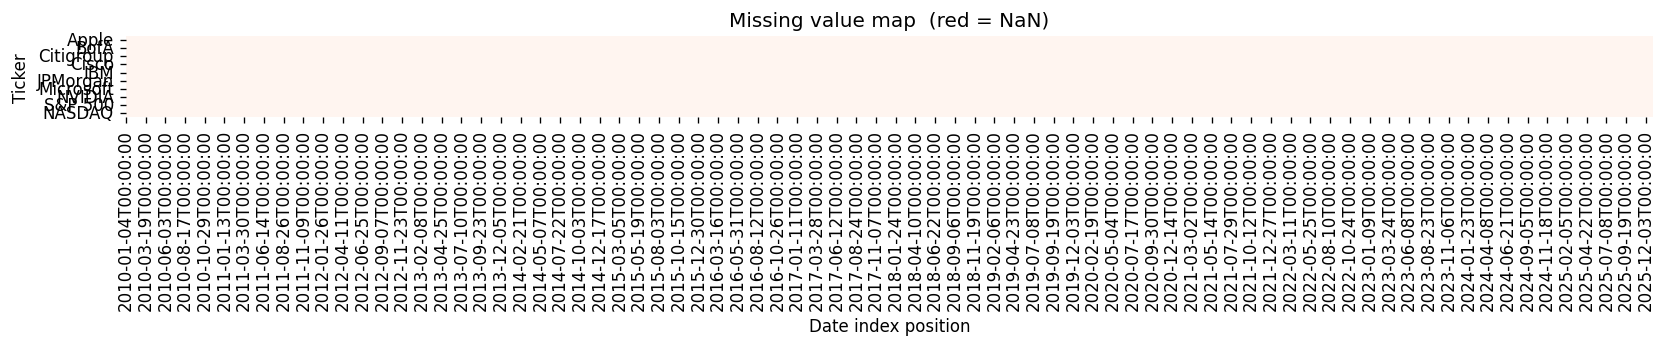

In [27]:
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(prices.isnull().astype(int).rename(columns=NAMES).T,
            cbar=False, cmap='Reds', ax=ax)
ax.set_title('Missing value map  (red = NaN)')
ax.set_xlabel('Date index position')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_value_map.png', bbox_inches='tight')
plt.show()


In [28]:
for ticker in prices.columns:
    s = prices[ticker]
    if not s.isnull().any():
        continue
    is_nan  = s.isnull()
    changes = is_nan.astype(int).diff().fillna(0)
    starts  = prices.index[changes == 1].tolist()
    ends    = prices.index[changes == -1].tolist()
    if is_nan.iloc[0]:  starts = [prices.index[0]] + starts
    if is_nan.iloc[-1]: ends   = ends + [prices.index[-1]]
    print(f"{NAMES[ticker]:15s}: {len(starts)} NaN block(s)")
    for s_, e_ in zip(starts, ends):
        print(f"  {s_.date()} to {e_.date()}  ({(e_ - s_).days + 1}d)")


## 5. Price Sanity Checks

In [29]:
# zero or negative prices
z_neg = (prices <= 0).sum().rename(NAMES)
print("Zero/negative prices:"); print(z_neg.to_string())

# extreme single-day moves
chg = prices.pct_change()
print("\nSingle-day moves > 40%:")
found = False
for t in prices.columns:
    ex = chg[t][chg[t].abs() > 0.40].dropna()
    if len(ex):
        found = True
        print(f"  {NAMES[t]:15s}: {len(ex)} events")
        for d, v in ex.items():
            print(f"    {d.date()}  {v*100:+.2f}%")
if not found:
    print("  None found above threshold.")


Zero/negative prices:
Ticker
Apple        0
BofA         0
Citigroup    0
Cisco        0
IBM          0
JPMorgan     0
Microsoft    0
NVIDIA       0
S&P 500      0
NASDAQ       0

Single-day moves > 40%:
  None found above threshold.


## 6. Outliers in Log Returns

In [30]:
ret_raw = np.log(prices / prices.shift(1)).dropna()

Z_THR, MAD_THR = 4.0, 3.5
rows = []
for t in ret_raw.columns:
    r  = ret_raw[t].dropna()
    zs = np.abs(stats.zscore(r))
    med, mad = r.median(), np.median(np.abs(r - r.median()))
    mz = 0.6745 * (r - med) / mad if mad > 0 else pd.Series(0, index=r.index)
    rows.append({
        'Asset':       NAMES[t],
        'N':           len(r),
        'Z |>4|':      int((zs > Z_THR).sum()),
        'MAD |>3.5|':  int((np.abs(mz) > MAD_THR).sum()),
        'Max |ret| %': round(r.abs().max() * 100, 3),
        'Date':        r.abs().idxmax().date(),
    })

out_df = pd.DataFrame(rows).set_index('Asset')
print(out_df.to_string())


              N  Z |>4|  MAD |>3.5|  Max |ret| %        Date
Asset                                                       
Apple      4022      20          96    14.262000  2025-04-09
BofA       4022      20         107    22.713000  2011-08-08
Citigroup  4022      25         123    21.441000  2020-03-16
Cisco      4022      29         119    17.686000  2010-11-11
IBM        4022      33         113    13.755000  2020-03-12
JPMorgan   4022      24         113    16.562000  2020-03-13
Microsoft  4022      25          82    15.945000  2020-03-16
NVIDIA     4022      22          85    26.088000  2016-11-11
S&P 500    4022      28         144    12.765000  2020-03-16
NASDAQ     4022      18         125    13.149000  2020-03-16


In [31]:
CRISIS = {'2020-03': 'COVID crash', '2020-02': 'COVID onset',
          '2008': 'GFC', '2009': 'GFC', '2010-05-06': 'Flash Crash'}

for t in ret_raw.columns:
    r  = ret_raw[t].dropna()
    zs = np.abs(stats.zscore(r))
    outs = r[zs > Z_THR].sort_values(key=abs, ascending=False)
    if outs.empty: continue
    print(f"\n{NAMES[t]} ({t}): {len(outs)} outlier(s)")
    for dt, val in outs.items():
        tag = next((f'  [{lbl}]' for key, lbl in CRISIS.items() if key in str(dt)), '')
        print(f"  {dt.date()}  {val*100:+.4f}%{tag}")



Apple (AAPL): 20 outlier(s)
  2025-04-09  +14.2618%
  2020-03-16  -13.7708%  [COVID crash]
  2013-01-24  -13.1884%
  2020-03-13  +11.3157%  [COVID crash]
  2019-01-03  -10.4924%
  2020-03-12  -10.3978%  [COVID crash]
  2020-07-31  +9.9563%
  2025-04-03  -9.7014%
  2020-03-24  +9.5606%  [COVID crash]
  2020-03-02  +8.9018%  [COVID crash]
  2022-11-10  +8.5236%
  2012-04-25  +8.5023%
  2020-04-06  +8.3640%
  2020-09-03  -8.3448%
  2014-01-28  -8.3303%
  2020-03-09  -8.2395%  [COVID crash]
  2014-04-24  +7.8794%
  2025-04-04  -7.5680%
  2010-05-10  +7.4056%
  2022-10-28  +7.2835%

BofA (BAC): 20 outlier(s)
  2011-08-08  -22.7130%
  2020-03-16  -16.7205%  [COVID crash]
  2020-03-13  +16.3786%  [COVID crash]
  2020-03-09  -15.9024%  [COVID crash]
  2011-08-09  +15.4809%
  2020-03-24  +15.1144%  [COVID crash]
  2020-11-09  +13.2708%
  2025-04-03  -11.7245%
  2011-08-10  -11.5647%
  2020-06-11  -10.5778%
  2011-08-24  +10.3930%
  2011-10-03  -10.1374%
  2020-03-12  -10.0130%  [COVID crash]
 

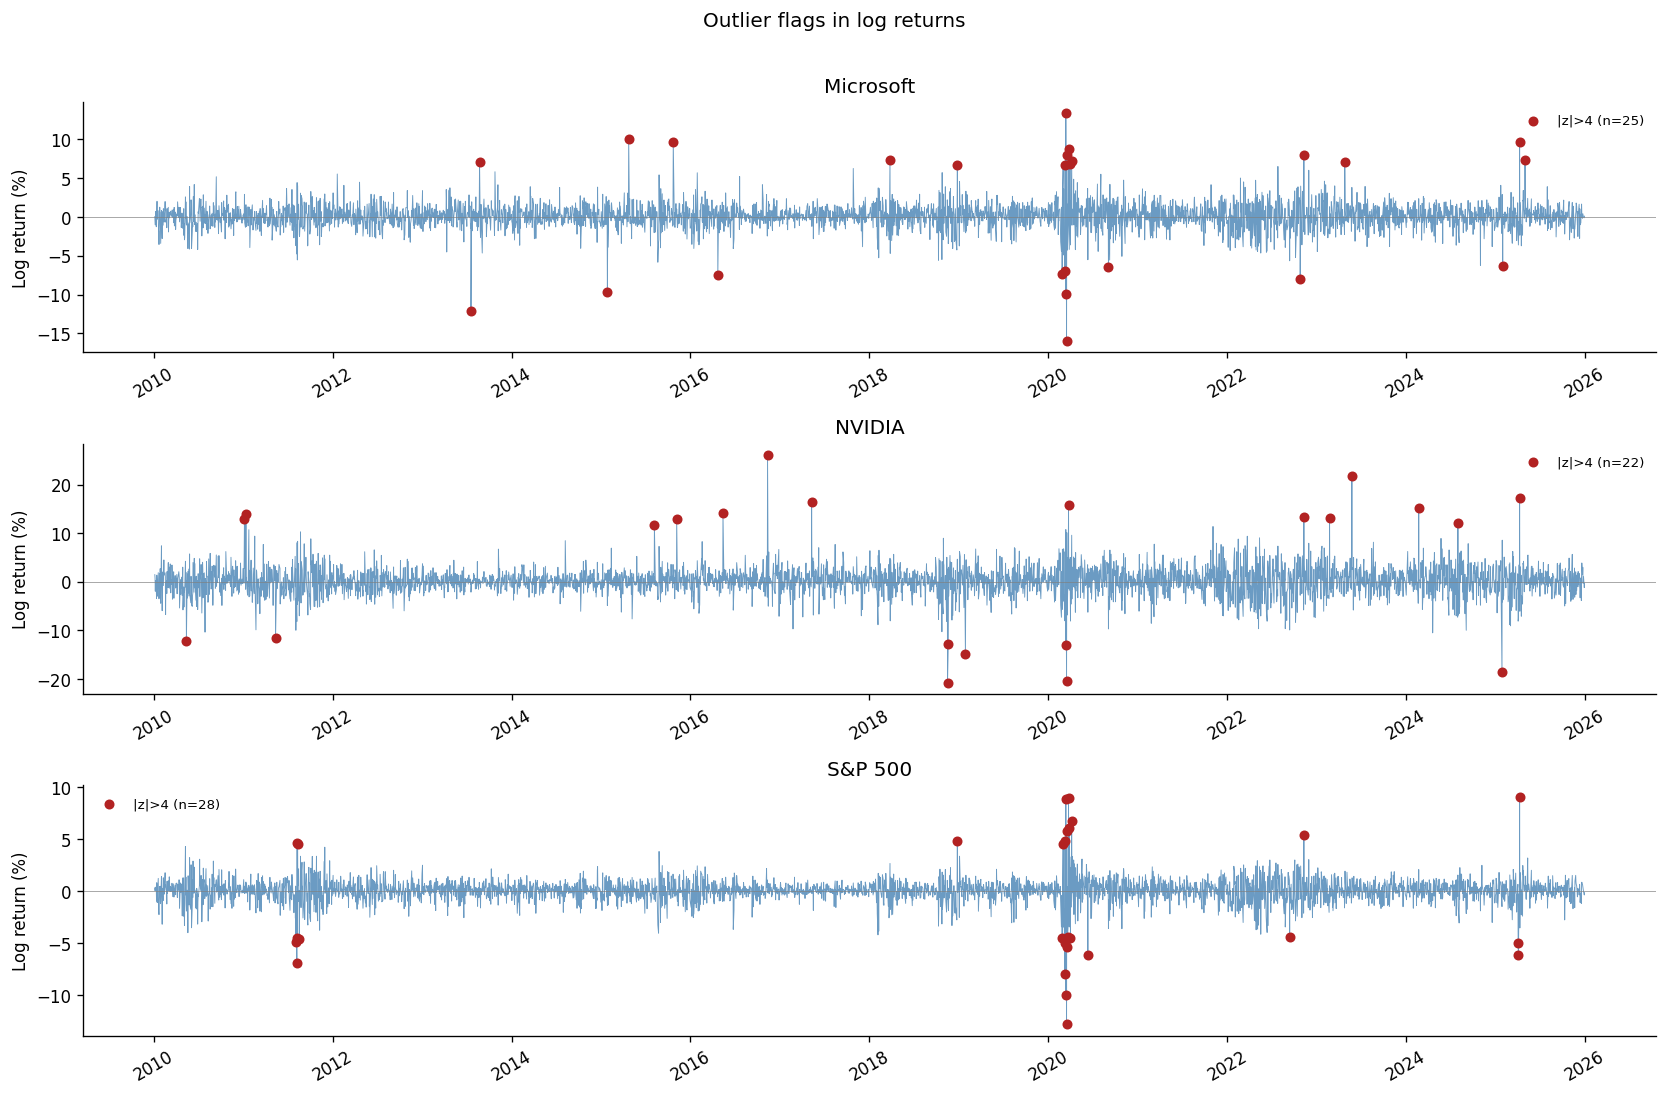

In [32]:
focus = ['MSFT', 'NVDA', '^GSPC']
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, t in zip(axes, focus):
    r  = ret_raw[t].dropna()
    zs = np.abs(stats.zscore(r))
    outs = r[zs > Z_THR]
    ax.plot(r.index, r * 100, linewidth=0.55, alpha=0.8, color='steelblue')
    if not outs.empty:
        ax.scatter(outs.index, outs * 100, color='firebrick', s=25, zorder=5,
                   label=f'|z|>{Z_THR:.0f} (n={len(outs)})')
    ax.axhline(0, color='grey', linewidth=0.4)
    ax.set_title(NAMES[t])
    ax.set_ylabel('Log return (%)')
    ax.legend(frameon=False, fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Outlier flags in log returns', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'outlier_flags.png', bbox_inches='tight')
plt.show()


## 7. Outlier Treatment

In [33]:
# extreme events are genuine (COVID, GFC) — retain raw returns for GARCH
# winsorise at 0.5/99.5 for LSTM feature set only
def winsorise(s, lo=0.005, hi=0.995):
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

ret_wins = ret_raw.apply(winsorise)

for t in ret_raw.columns:
    n = (ret_raw[t] != ret_wins[t]).sum()
    print(f"{NAMES[t]:15s}: {n} observations clipped")


Apple          : 42 observations clipped
BofA           : 42 observations clipped
Citigroup      : 42 observations clipped
Cisco          : 42 observations clipped
IBM            : 42 observations clipped
JPMorgan       : 42 observations clipped
Microsoft      : 42 observations clipped
NVIDIA         : 42 observations clipped
S&P 500        : 42 observations clipped
NASDAQ         : 42 observations clipped


## 8. Missing Value Treatment & Final Clean

In [34]:
prices_clean = prices.ffill(limit=2).bfill().dropna(how='any')

print(f"Before: {len(prices)} rows")
print(f"After : {len(prices_clean)} rows  (dropped: {len(prices) - len(prices_clean)})")
print(f"Period: {prices_clean.index.min().date()} to {prices_clean.index.max().date()}")
print(f"NaN remaining: {prices_clean.isnull().sum().sum()}")


Before: 4023 rows
After : 4023 rows  (dropped: 0)
Period: 2010-01-04 to 2025-12-30
NaN remaining: 0


## 9. Post-Clean Validation

In [35]:
checks = pd.DataFrame({
    NAMES[t]: {
        'N obs':         len(prices_clean[t]),
        'NaN':           prices_clean[t].isnull().sum(),
        'Min price':     round(prices_clean[t].min(), 2),
        'Max price':     round(prices_clean[t].max(), 2),
        'Zero/neg':      (prices_clean[t] <= 0).any(),
        'Dup dates':     prices_clean.index.duplicated().sum(),
    }
    for t in prices_clean.columns
}).T
print(checks.to_string())
print(f"\nAll clean: {checks['NaN'].eq(0).all() and not checks['Zero/neg'].any()}")


          N obs NaN   Min price    Max price Zero/neg Dup dates
Apple      4023   0    5.750000   285.660000    False         0
BofA       4023   0    3.860000    55.640000    False         0
Citigroup  4023   0   16.990000   120.360000    False         0
Cisco      4023   0    8.900000    79.390000    False         0
IBM        4023   0   66.470000   310.910000    False         0
JPMorgan   4023   0   19.210000   326.020000    False         0
Microsoft  4023   0   17.280000   538.660000    False         0
NVIDIA     4023   0    0.200000   206.780000    False         0
S&P 500    4023   0 1022.580000  6932.050000    False         0
NASDAQ     4023   0 2091.790000 23958.470000    False         0

All clean: True


## 10. Clean Log Returns

In [36]:
ret_clean = np.log(prices_clean / prices_clean.shift(1)).dropna()
pct_clean = prices_clean.pct_change().dropna()

print(f"Shape: {ret_clean.shape}")
print(ret_clean.describe().rename(columns=NAMES).round(6).to_string())


Shape: (4022, 10)
Ticker       Apple        BofA   Citigroup       Cisco         IBM    JPMorgan   Microsoft      NVIDIA     S&P 500      NASDAQ
count  4022.000000 4022.000000 4022.000000 4022.000000 4022.000000 4022.000000 4022.000000 4022.000000 4022.000000 4022.000000
mean      0.000933    0.000376    0.000382    0.000391    0.000353    0.000603    0.000758    0.001515    0.000449    0.000576
std       0.017741    0.020958    0.021347    0.016293    0.014379    0.017372    0.016053    0.028614    0.010943    0.012952
min      -0.137708   -0.227130   -0.214414   -0.176865   -0.137548   -0.162106   -0.159453   -0.207712   -0.127652   -0.131492
25%      -0.007418   -0.009625   -0.009375   -0.006481   -0.006232   -0.007505   -0.007083   -0.012464   -0.003808   -0.004827
50%       0.000994    0.000464    0.000477    0.000506    0.000612    0.000668    0.000698    0.001776    0.000702    0.001105
75%       0.010214    0.010655    0.010332    0.008010    0.007235    0.009136    0.009089   

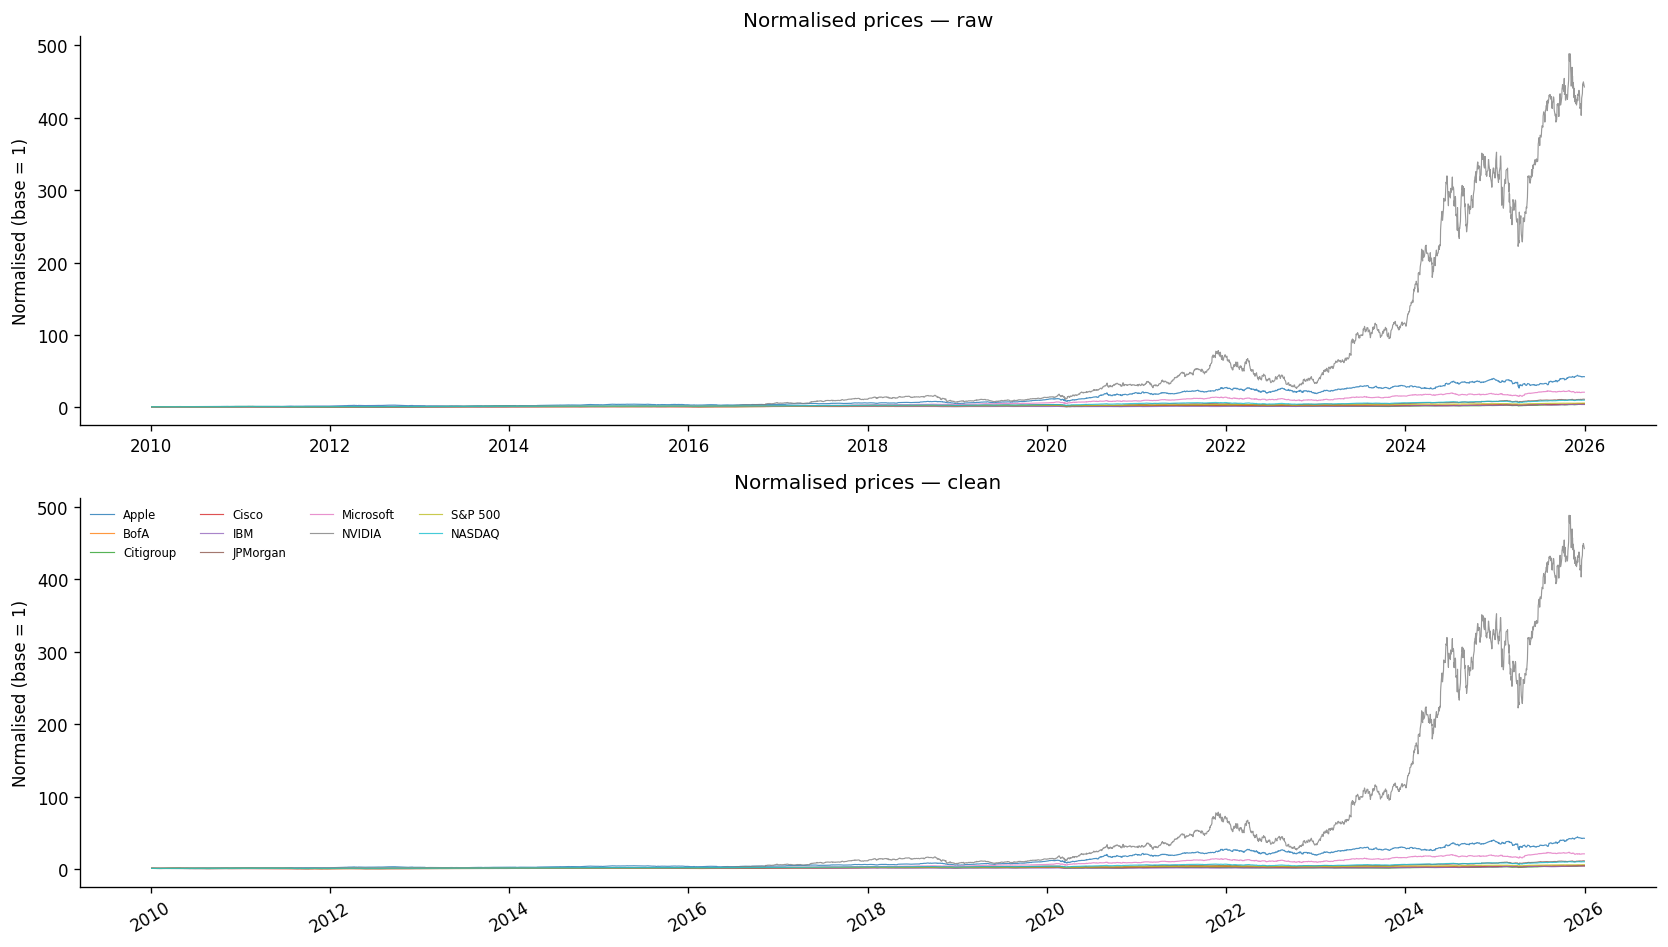

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for i, t in enumerate(prices.columns):
    fv = prices[t].first_valid_index()
    if fv: axes[0].plot(prices[t] / prices[t][fv], color=PALETTE[i], lw=0.7, alpha=0.8)
axes[0].set_title('Normalised prices — raw')
axes[0].set_ylabel('Normalised (base = 1)')

for i, t in enumerate(prices_clean.columns):
    axes[1].plot(prices_clean[t] / prices_clean[t].iloc[0],
                 color=PALETTE[i], lw=0.7, alpha=0.8, label=NAMES[t])
axes[1].set_title('Normalised prices — clean')
axes[1].set_ylabel('Normalised (base = 1)')
axes[1].legend(ncol=4, fontsize=7, frameon=False)
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'before_after_cleaning.png', bbox_inches='tight')
plt.show()


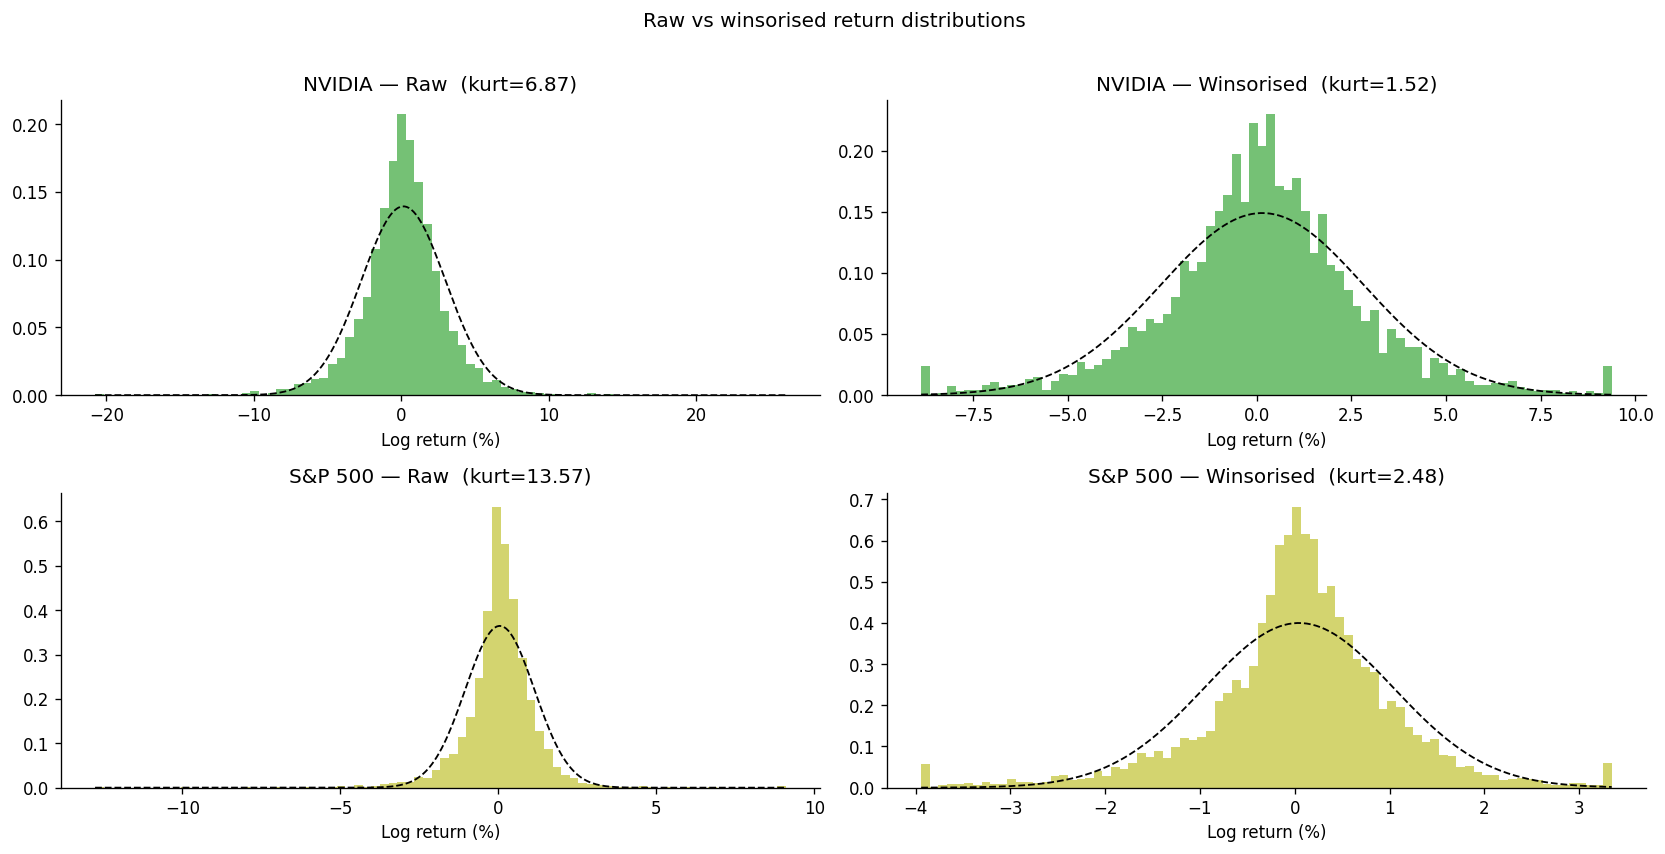

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()
pairs = [('NVDA', 'Raw'), ('NVDA', 'Winsorised'), ('^GSPC', 'Raw'), ('^GSPC', 'Winsorised')]
src   = {'Raw': ret_raw, 'Winsorised': ret_wins}

for ax, (t, label) in zip(axes, pairs):
    r = src[label][t].dropna()
    ax.hist(r * 100, bins=80, density=True, alpha=0.65, color=PALETTE[TICKERS.index(t)])
    x = np.linspace(r.min() * 100, r.max() * 100, 300)
    ax.plot(x, sp_norm.pdf(x, r.mean() * 100, r.std() * 100), 'k--', lw=1.1)
    ax.set_title(f'{NAMES[t]} — {label}  (kurt={float(r.kurtosis()):.2f})')
    ax.set_xlabel('Log return (%)')
plt.suptitle('Raw vs winsorised return distributions', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribution_raw_vs_wins.png', bbox_inches='tight')
plt.show()


## 11. Export

In [39]:
prices_clean.to_csv(DATA_DIR / 'prices_clean.csv')
ret_clean.to_csv(DATA_DIR / 'log_returns_clean.csv')
ret_wins.to_csv(DATA_DIR / 'log_returns_winsorised.csv')

for f in ['prices_clean.csv', 'log_returns_clean.csv', 'log_returns_winsorised.csv']:
    kb = (DATA_DIR / f).stat().st_size / 1024
    print(f"{f:40s}  {kb:6.1f} KB")


prices_clean.csv                           754.6 KB
log_returns_clean.csv                      887.7 KB
log_returns_winsorised.csv                 887.9 KB
